Data Loaded: (891, 12)


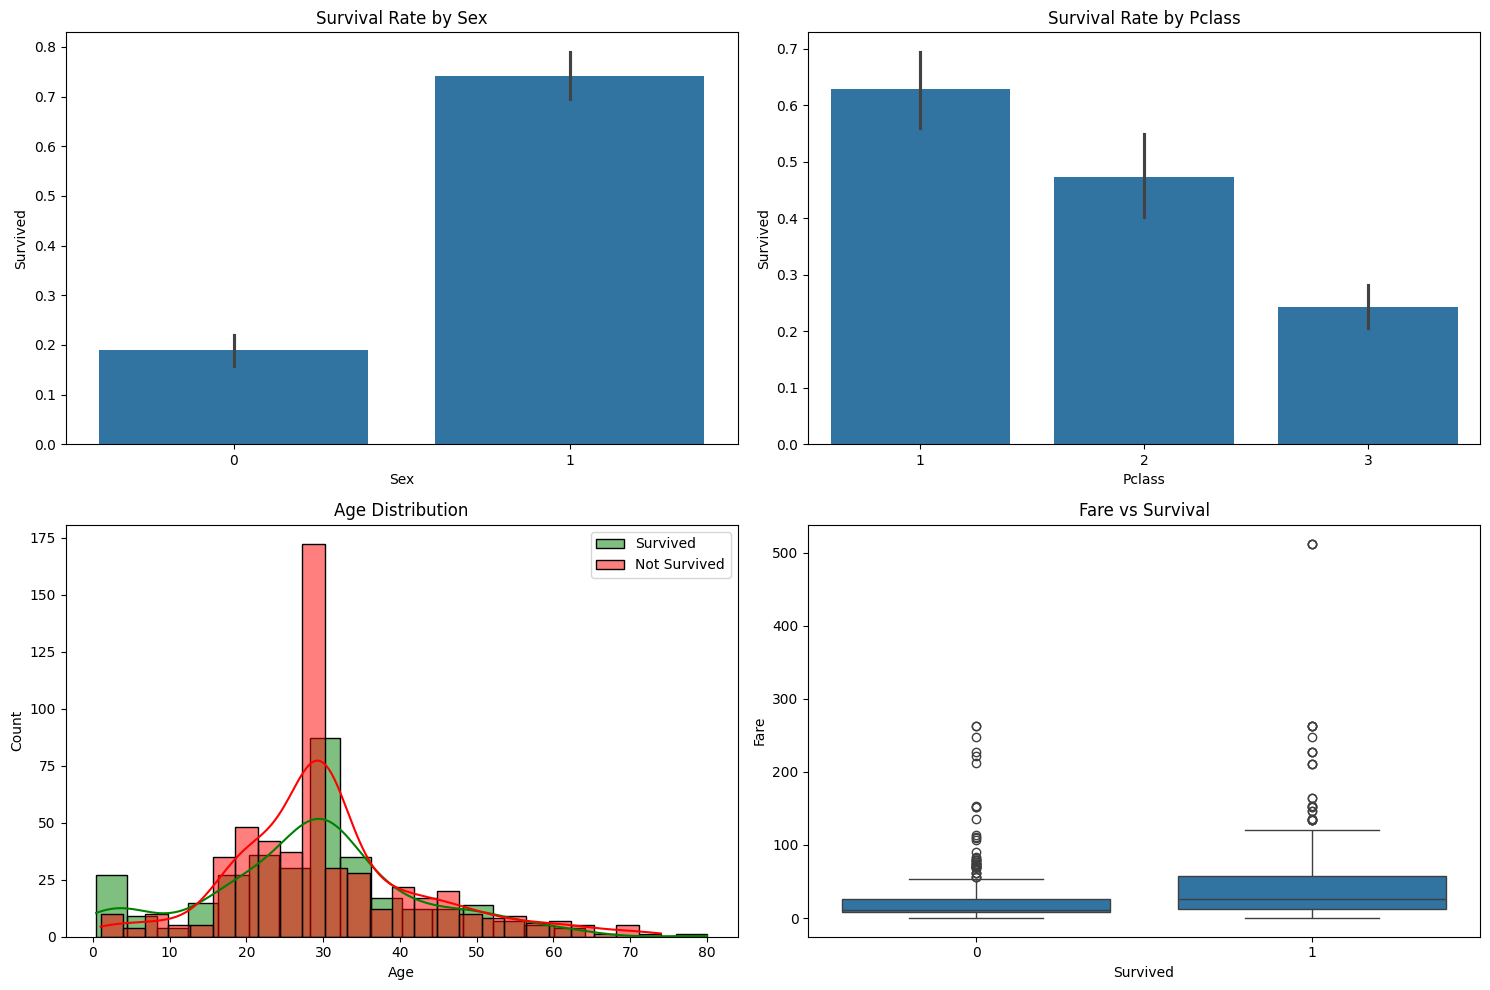

✅ Cleaning + 4 grafik selesai


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Download data langsung
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
print("Data Loaded:", df.shape)

# 2. Cleaning
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df_clean = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]
df_clean.to_csv('data_clean.csv', index=False)

# 3. VISUALISASI
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival Rate by Sex')

plt.subplot(2, 2, 2)
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rate by Pclass')

plt.subplot(2, 2, 3)
sns.histplot(df[df['Survived']==1]['Age'], color='green', label='Survived', kde=True)
sns.histplot(df[df['Survived']==0]['Age'], color='red', label='Not Survived', kde=True)
plt.title('Age Distribution')
plt.legend()

plt.subplot(2, 2, 4)
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title('Fare vs Survival')

plt.tight_layout()
plt.show()

print("✅ Cleaning + 4 grafik selesai")

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import joblib

X = df_clean.drop('Survived', axis=1)
y = df_clean['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)
print("Akurasi Model:", round(accuracy_score(y_test, preds)*100, 2), "%")

# Simpan model
joblib.dump(model, 'titanic_model.pkl')
print("✅ Model disimpan")

Akurasi Model: 78.77 %
✅ Model disimpan


In [ ]:
%%writefile app.py
import streamlit as st
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model = joblib.load('titanic_model.pkl')
df = pd.read_csv('data_clean.csv')

st.title("🚢 Titanic Survival Predictor")
st.write("Prediksi apakah penumpang akan selamat")

tab1, tab2 = st.tabs(["🔮 Predict", "📊 Data Visualization"])

with tab1:
    col1, col2 = st.columns(2)
    with col1:
        pclass = st.selectbox("Pclass", [1, 2, 3])
        sex = st.selectbox("Sex", ["male", "female"])
    with col2:
        age = st.number_input("Age", 1, 100, 30)
        fare = st.number_input("Fare", 0.0, 500.0, 50.0)

    if st.button("Predict Now"):
        sex_num = 0 if sex == "male" else 1
        input_df = pd.DataFrame([[pclass, sex_num, age, fare]], columns=['Pclass', 'Sex', 'Age', 'Fare'])
        prediction = model.predict(input_df)[0]
        prob = model.predict_proba(input_df)[0][1]

        if prediction == 1:
            st.success(f"✅ SURVIVED! Probability: {prob:.2f}")
        else:
            st.error(f"❌ NOT SURVIVED. Probability: {1-prob:.2f}")

with tab2:
    st.subheader("Data Insights")
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    sns.barplot(x='Sex', y='Survived', data=df, ax=ax[0])
    ax[0].set_title('Survival by Sex')
    sns.barplot(x='Pclass', y='Survived', data=df, ax=ax[1])
    ax[1].set_title('Survival by Pclass')
    st.pyplot(fig)

Writing app.py


In [ ]:
xk%%writefile requirements.txt
streamlit
pandas
scikit-learn
joblib
matplotlib
seaborn

Writing requirements.txt
